# Smell Reports vs. Plume Data: Cross-Reference Analysis
### Do community-reported bad smell days align with our modeled pollution days?

---

The smell report data comes from the SmellPGH app, where residents rate air quality on a 1–5 scale. We're only interested in reports rated 3–5 (1s and 2s are considered ambient / not noteworthy). For each day, we sum the number of qualifying reports and bin them into the same color categories used in the existing SmellPGH visualization:

| Reports | Color | Meaning |
|---------|-------|---------|
| 0–15    | `#ededed` (very light grey) | Quiet day |
| 16–31   | `#dbdbdb` | Mild |
| 32–45   | `#afafaf` | Moderate |
| 46–76   | `#848383` | Notable |
| 77–182  | `#545454` | Bad |
| 183+    | `#000000` (black) | Very bad |

We then cross-reference these daily smell totals against the plume model's regional sum (from the facility analysis) to ask: **when people are reporting bad smells, does our model agree it was a bad pollution day? And when it doesn't, why not?**

## Setup

Just loading the libraries. pandas handles tables, numpy does math, matplotlib makes charts, mpatches is specifically for drawing rectangles and custom legend symbols.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')
print('imports OK')

imports OK


## Configuration

In [ ]:
SMELL_REPORTS_CSV = './smell_reports.csv'   # ← file path for the smell reports
PLUME_RANKINGS_CSV = './daily_rankings.csv' # ← output from the ranking notebook

# Only count reports at or above this smell value (1-2 are ignored)
MIN_SMELL_VALUE = 3

# Color bins matching the existing SmellPGH visualization
COLOR_BINS   = [0, 16, 32, 46, 77, 183]
COLOR_RANGE  = ['#ededed', '#dbdbdb', '#afafaf', '#848383', '#545454', '#000000']
BIN_LABELS   = ['0–15', '16–31', '32–45', '46–76', '77–182', '183+']

# Notification threshold from the ranking notebook
TOP_FRACTION = 0.10

## Load and process smell reports

Here, we take the raw CSV (one row per individual smell report) and collapse it down to one row per day.

In [6]:
raw = pd.read_csv(SMELL_REPORTS_CSV)
print(f'Raw reports: {len(raw):,}')
print(f'Smell value distribution:')
print(raw['smell value'].value_counts().sort_index().to_string())

# Filter to 3-5 only
filtered = raw[raw['smell value'] >= MIN_SMELL_VALUE].copy()
print(f'\nAfter filtering to ≥{MIN_SMELL_VALUE}: {len(filtered):,} reports')

# Parse date — format is '01/01/2024 02:01:16 -05:00'
filtered['date'] = pd.to_datetime(
    filtered['date & time'].str[:10], format='%m/%d/%Y'
)
filtered['date_str'] = filtered['date'].dt.strftime('%Y%m%d')

# Aggregate: count reports per day
smell_daily = (
    filtered.groupby('date_str')
    .agg(
        n_reports=('smell value', 'count'),
        mean_smell=('smell value', 'mean'),
        n_value_5=('smell value', lambda x: (x == 5).sum()),
    )
    .reset_index()
)
smell_daily['date'] = pd.to_datetime(smell_daily['date_str'], format='%Y%m%d')

# Assign color bin
def assign_bin(n):
    for i in range(len(COLOR_BINS) - 1, -1, -1):
        if n >= COLOR_BINS[i]:
            return i
    return 0

smell_daily['bin_idx'] = smell_daily['n_reports'].apply(assign_bin)
smell_daily['color']   = smell_daily['bin_idx'].apply(lambda i: COLOR_RANGE[i])
smell_daily['bin_label'] = smell_daily['bin_idx'].apply(lambda i: BIN_LABELS[i])

print(f'\nDays with ≥1 qualifying report: {len(smell_daily)}')
print(f'\nReport count by bin:')
print(smell_daily['bin_label'].value_counts().reindex(BIN_LABELS).to_string())

Raw reports: 11,608
Smell value distribution:
smell value
1     593
2     421
3    2753
4    3902
5    3939

After filtering to ≥3: 10,594 reports

Days with ≥1 qualifying report: 365

Report count by bin:
bin_label
0–15      174
16–31      89
32–45      31
46–76      39
77–182     29
183+        3


## Load plume rankings

This is the `daily_rankings.csv` output from the facility ranking notebook, which is one row per day with the regional sum, rank, and notification flag. It recomputes the notify column fresh using whatever TOP_FRACTION is set to, so if you change that setting here it updates automatically.

In [7]:
plume = pd.read_csv(PLUME_RANKINGS_CSV)
plume['date_str'] = pd.to_datetime(plume['date']).dt.strftime('%Y%m%d')

# Recompute notify flag in case TOP_FRACTION changed
threshold = plume['regional_sum'].quantile(1 - TOP_FRACTION)
plume['notify'] = plume['regional_sum'] >= threshold

print(f'Plume data: {len(plume)} days')
print(f'Date range: {plume["date_str"].min()} → {plume["date_str"].max()}')
print(f'Notify threshold (top {TOP_FRACTION*100:.0f}%): {threshold:.2f}')
print(f'Notification days: {plume["notify"].sum()}')

Plume data: 366 days
Date range: 20240101 → 20241231
Notify threshold (top 10%): 20721.66
Notification days: 37


## Merge smell and plume data

Join on date. Days with no smell reports get `n_reports = 0`. Days with no plume data (the model didn't run, or the plume didn't reach the domain) get `regional_sum = NaN`.

In [8]:
# Build a full calendar of all days in 2024
all_days = pd.DataFrame({
    'date_str': pd.date_range('2024-01-01', '2024-12-31').strftime('%Y%m%d')
})

merged = (
    all_days
    .merge(smell_daily[['date_str','n_reports','mean_smell','bin_idx','color','bin_label']],
           on='date_str', how='left')
    .merge(plume[['date_str','regional_sum','regional_max','rank','notify']],
           on='date_str', how='left')
)

merged['n_reports'] = merged['n_reports'].fillna(0).astype(int)
merged['bin_idx']   = merged['bin_idx'].fillna(0).astype(int)
merged['color']     = merged['color'].fillna(COLOR_RANGE[0])
merged['bin_label'] = merged['bin_label'].fillna(BIN_LABELS[0])
merged['notify']    = merged['notify'].fillna(False)
merged['date']      = pd.to_datetime(merged['date_str'], format='%Y%m%d')

print(f'Merged table: {len(merged)} days (full 2024 calendar)')
print(f'Days with smell reports: {(merged["n_reports"] > 0).sum()}')
print(f'Days with plume data:    {merged["regional_sum"].notna().sum()}')
print(f'Days with both:          {(merged["n_reports"] > 0 & merged["regional_sum"].notna()).sum()}')
print()
print(merged[['date_str','n_reports','bin_label','regional_sum','rank','notify']].head(10).to_string(index=False))

Merged table: 366 days (full 2024 calendar)
Days with smell reports: 365
Days with plume data:    366
Days with both:          365

date_str  n_reports bin_label  regional_sum  rank  notify
20240101          3      0–15   6802.858398   307   False
20240102          8      0–15   6580.666992   314   False
20240103          1      0–15   8874.571289   267   False
20240104          2      0–15   5230.348145   342   False
20240105         28     16–31  20052.207031    47   False
20240106         13      0–15  16147.720703    96   False
20240107          3      0–15   6656.679688   311   False
20240108         11      0–15  13851.664062   138   False
20240109         11      0–15   8937.168945   266   False
20240110          4      0–15   4954.278320   349   False


## Visualization 1: Calendar heatmap

The smell report color bins shown as a full-year calendar, with notification days marked. Each day is a small colored rectangle, laid out in a 12-column (months) × 31-row (days) grid. The x position is the month minus 1 (so January = 0, December = 11), the y position is 30 - day which flips day 1 to the top. Each rectangle is colored with the smell bin color for that day. If that day was also a plume notification day, an orange dot gets drawn in the center of the rectangle on top.

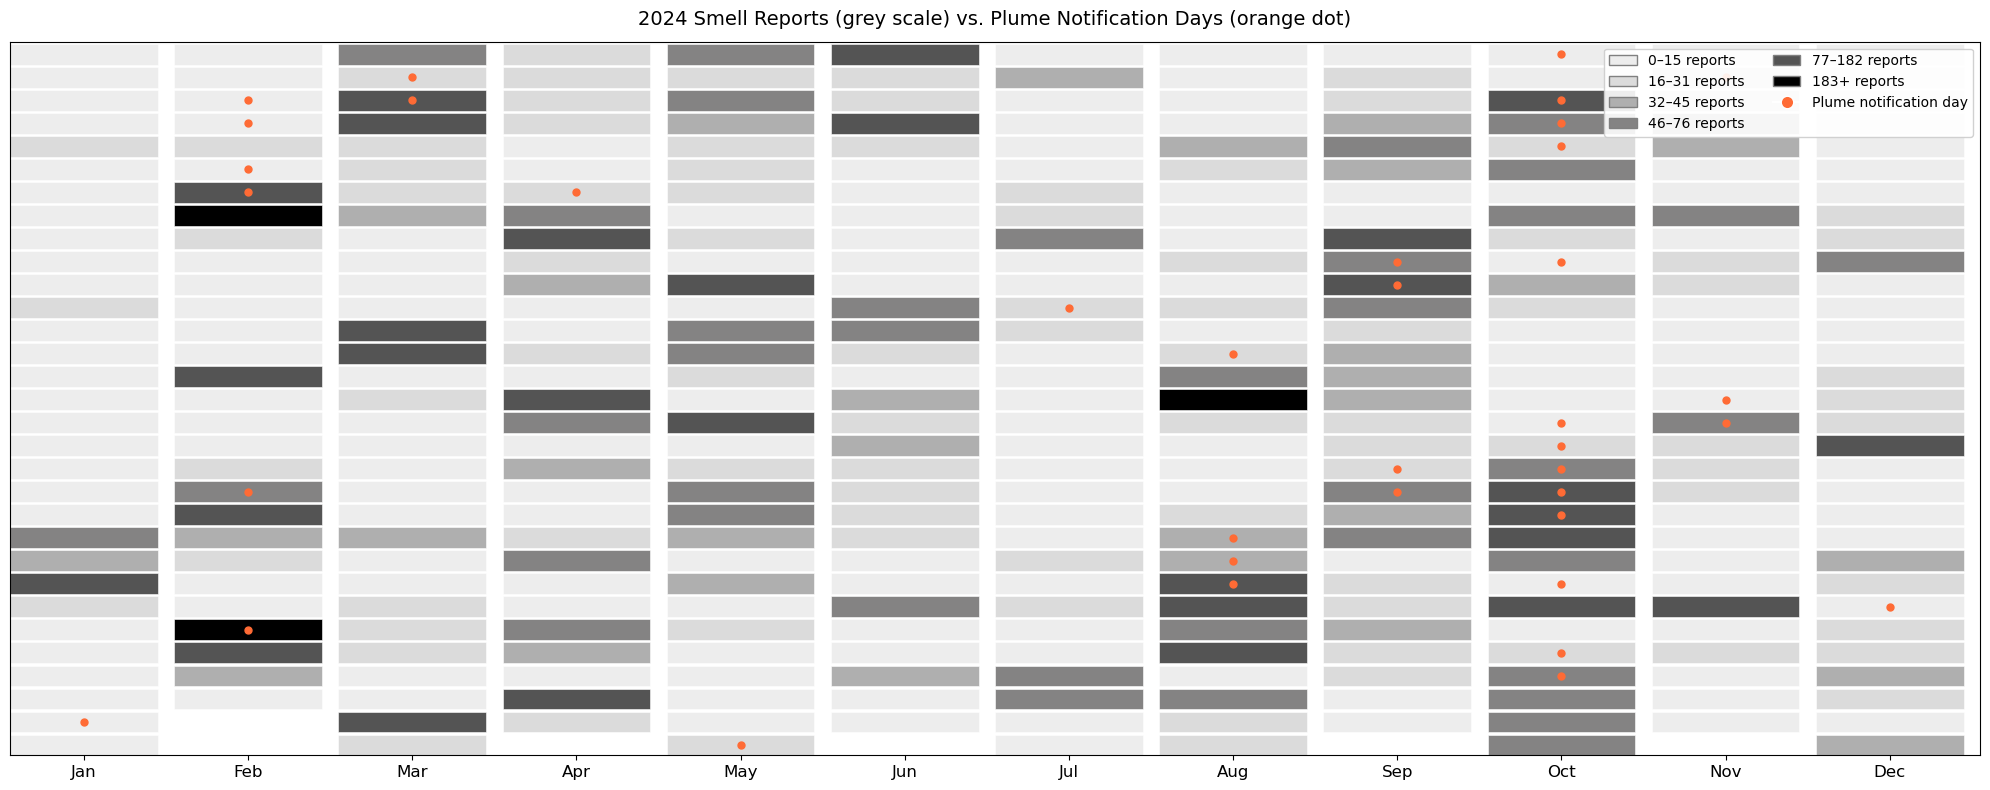

In [9]:
fig, ax = plt.subplots(figsize=(20, 8))

months = merged['date'].dt.month.unique()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for _, row in merged.iterrows():
    month = row['date'].month - 1      # 0-indexed x
    day   = row['date'].day - 1        # 0-indexed y (1 at top)

    # Smell color block
    rect = mpatches.Rectangle(
        (month, 30 - day), 0.9, 0.9,
        facecolor=row['color'], edgecolor='white', linewidth=0.4
    )
    ax.add_patch(rect)

    # Orange dot for notification days
    if row['notify']:
        ax.plot(month + 0.45, 30 - day + 0.45, 'o',
                color='#FF6B35', markersize=5, zorder=5)

ax.set_xlim(0, 12)
ax.set_ylim(0, 31)
ax.set_xticks([i + 0.45 for i in range(12)])
ax.set_xticklabels(month_names, fontsize=12)
ax.set_yticks([])
ax.set_title('2024 Smell Reports (grey scale) vs. Plume Notification Days (orange dot)',
             fontsize=14, pad=12)

# Legend
legend_patches = [
    mpatches.Patch(facecolor=c, edgecolor='grey', label=f'{l} reports')
    for c, l in zip(COLOR_RANGE, BIN_LABELS)
]
legend_patches.append(
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#FF6B35',
               markersize=9, label='Plume notification day')
)
ax.legend(handles=legend_patches, loc='upper right', fontsize=10,
          framealpha=0.9, ncol=2)

plt.tight_layout()
plt.savefig('smell_vs_plume_calendar.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 2: Scatter: smell reports vs. regional sum

Each dot is one day of the year. The x position is how many smell reports came in that day. The y position is the plume regional sum. The dot's color matches the smell bin color.
On top of that it draws orange rings around the dots that were plume notification days, a dashed horizontal line at the notification threshold, and a dotted trend line showing the overall direction of the relationship. The quadrant labels ("High plume, few reports" etc.) are just text placed at specific coordinates to help read the chart.

The correlation at the bottom is a single number summarizing how closely the two signals move together. r is called the Pearson correlation coefficient. 1.0 is a perfect positive relationship (when one goes up, the other always goes up by a proportional amount), 0 would ne no relationship, and -1.0 is an inverse relationship. So, r = 0.356 means weak relationship (some relationship but noisy).





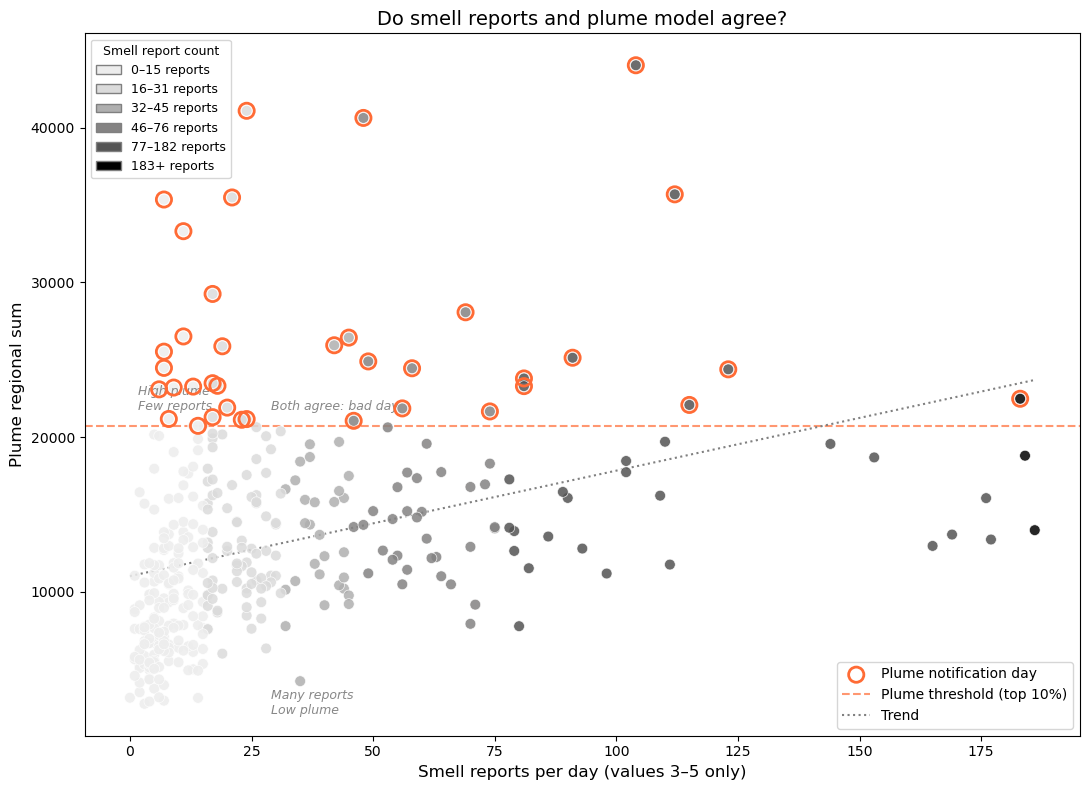

Correlation between smell reports and regional sum: r = 0.356


In [10]:
has_both = merged.dropna(subset=['regional_sum'])

fig, ax = plt.subplots(figsize=(11, 8))

sc = ax.scatter(
    has_both['n_reports'],
    has_both['regional_sum'],
    c=has_both['color'],
    s=60, alpha=0.85, edgecolors='white', linewidth=0.5, zorder=3
)

# Mark notification days with a ring
notify_days = has_both[has_both['notify']]
ax.scatter(
    notify_days['n_reports'], notify_days['regional_sum'],
    s=120, facecolors='none', edgecolors='#FF6B35', linewidth=2,
    zorder=4, label='Plume notification day'
)

# Threshold lines
ax.axhline(threshold, color='#FF6B35', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Plume threshold (top {TOP_FRACTION*100:.0f}%)')

# Trend line
valid = has_both.dropna(subset=['n_reports','regional_sum'])
z = np.polyfit(valid['n_reports'], valid['regional_sum'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['n_reports'].min(), valid['n_reports'].max(), 100)
ax.plot(x_line, p(x_line), color='grey', linestyle=':', linewidth=1.5, label='Trend')

# Quadrant labels
x_mid = has_both['n_reports'].median()
y_mid = threshold
ax.text(x_mid * 0.1,  threshold * 1.05, 'High plume\nFew reports',
        fontsize=9, color='#888', style='italic')
ax.text(has_both['n_reports'].quantile(0.7), threshold * 1.05, 'Both agree: bad day',
        fontsize=9, color='#888', style='italic')
ax.text(has_both['n_reports'].quantile(0.7), threshold * 0.1, 'Many reports\nLow plume',
        fontsize=9, color='#888', style='italic')

# Smell bin legend
smell_patches = [
    mpatches.Patch(facecolor=c, edgecolor='grey', label=f'{l} reports')
    for c, l in zip(COLOR_RANGE, BIN_LABELS)
]
legend1 = ax.legend(handles=smell_patches, loc='upper left', fontsize=9,
                    title='Smell report count', title_fontsize=9)
ax.add_artist(legend1)
ax.legend(fontsize=10, loc='lower right')

ax.set_xlabel('Smell reports per day (values 3–5 only)', fontsize=12)
ax.set_ylabel('Plume regional sum', fontsize=12)
ax.set_title('Do smell reports and plume model agree?', fontsize=14)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('smell_vs_plume_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
corr = valid['n_reports'].corr(valid['regional_sum'])
print(f'Correlation between smell reports and regional sum: r = {corr:.3f}')

## Visualization 3: Timeline: both signals over the year

Two panels sharing the same x-axis (date). The top panel shows the plume regional sum for every day, with red bars on notification days and a dashed threshold line. The bottom panel shows smell report counts for every day, colored by bin. The x-axis shows month names placed at the first day of each month.


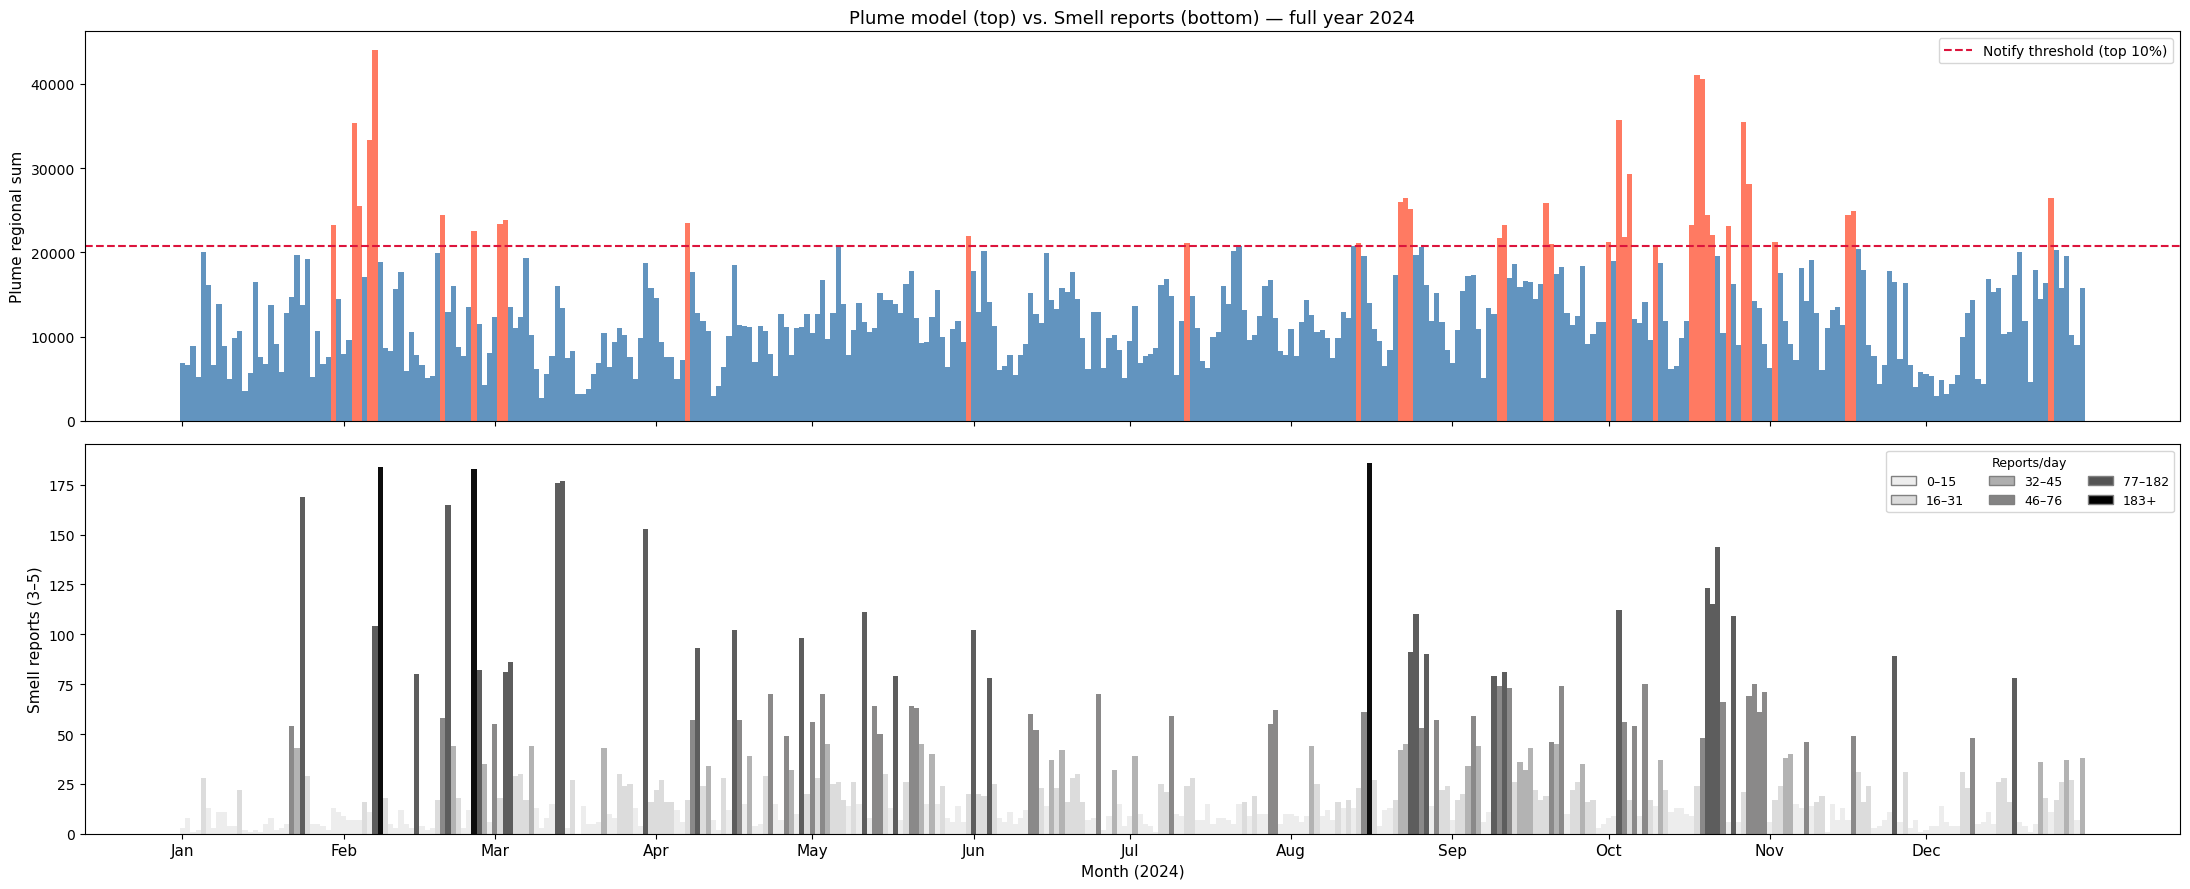

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 9), sharex=True)

# Top: plume regional sum
plume_colors = ['tomato' if n else 'steelblue' for n in merged['notify']]
ax1.bar(range(len(merged)), merged['regional_sum'], color=plume_colors,
        width=1.0, alpha=0.85)
ax1.axhline(threshold, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Notify threshold (top {TOP_FRACTION*100:.0f}%)')
ax1.set_ylabel('Plume regional sum', fontsize=11)
ax1.set_title('Plume model (top) vs. Smell reports (bottom) — full year 2024', fontsize=13)
ax1.legend(fontsize=10)
ax1.tick_params(axis='y', labelsize=10)

# Bottom: smell reports
for i, (_, row) in enumerate(merged.iterrows()):
    ax2.bar(i, row['n_reports'], color=row['color'], width=1.0, alpha=0.95)

ax2.set_ylabel('Smell reports (3–5)', fontsize=11)
ax2.tick_params(axis='y', labelsize=10)

# X-axis: month labels at the first day of each month
month_positions = []
month_labels_list = []
for i, row in merged.iterrows():
    if row['date'].day == 1:
        month_positions.append(i)
        month_labels_list.append(row['date'].strftime('%b'))

ax2.set_xticks(month_positions)
ax2.set_xticklabels(month_labels_list, fontsize=11)
ax2.set_xlabel('Month (2024)', fontsize=11)

# Smell legend on bottom panel
smell_patches = [
    mpatches.Patch(facecolor=c, edgecolor='grey', label=f'{l}')
    for c, l in zip(COLOR_RANGE, BIN_LABELS)
]
ax2.legend(handles=smell_patches, title='Reports/day', title_fontsize=9,
           fontsize=9, loc='upper right', ncol=3)

plt.tight_layout()
plt.savefig('smell_vs_plume_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## Disagreement analysis

Days where the two signals diverge could mean:
- **High plume, few reports** — pollution was real but people didn't smell it (wrong wind direction, nighttime, low population density in affected area, or the plume wasn't odorous)
- **Many reports, low plume** — community smelled something our model missed (different source, model underestimate, or odor from a facility not in our dataset)

Here, we put every day into one of four buckets based on whether each signal is above or below its threshold:

- Both bad — both above threshold → model and community agree it was bad
- Plume only — plume high but smell low → model fired but community was quiet
- Smell only — smell high but plume low → community flagged it but model didn't
- Neither — both below threshold → quiet day, both agree

In [12]:
has_both = merged.dropna(subset=['regional_sum']).copy()

# Define disagreement thresholds
smell_high = has_both['n_reports'].quantile(0.75)   # top 25% of smell days
plume_high = threshold                               # top 10% of plume days

both_high    = has_both[(has_both['n_reports'] >= smell_high) & (has_both['notify'])]
plume_only   = has_both[(has_both['n_reports'] <  smell_high) & (has_both['notify'])]
smell_only   = has_both[(has_both['n_reports'] >= smell_high) & (~has_both['notify'])]
neither      = has_both[(has_both['n_reports'] <  smell_high) & (~has_both['notify'])]

print(f'Smell high threshold (75th pct): {smell_high:.0f} reports/day')
print(f'Plume high threshold (top {TOP_FRACTION*100:.0f}%): {plume_high:.1f}')
print()
print(f'Both signals agree — BAD:  {len(both_high):3d} days  ← model and community agree')
print(f'Plume high, smell low:     {len(plume_only):3d} days  ← model flagged, community quiet')
print(f'Smell high, plume low:     {len(smell_only):3d} days  ← community flagged, model quiet')
print(f'Both signals agree — FINE: {len(neither):3d} days')
print()

print('--- Days model flagged but community was quiet (plume only) ---')
print(plume_only[['date_str','n_reports','regional_sum','rank']].sort_values('rank').to_string(index=False))

print('\n--- Days community flagged but model was quiet (smell only) ---')
print(smell_only[['date_str','n_reports','mean_smell','regional_sum']].sort_values('n_reports', ascending=False).to_string(index=False))

Smell high threshold (75th pct): 37 reports/day
Plume high threshold (top 10%): 20721.7

Both signals agree — BAD:   17 days  ← model and community agree
Plume high, smell low:      20 days  ← model flagged, community quiet
Smell high, plume low:      76 days  ← community flagged, model quiet
Both signals agree — FINE: 253 days

--- Days model flagged but community was quiet (plume only) ---
date_str  n_reports  regional_sum  rank
20241018         24  41094.132812     2
20241027         21  35489.500000     5
20240203          7  35356.308594     6
20240206         11  33308.792969     7
20241005         17  29250.957031     8
20241225         11  26503.750000    10
20240919         19  25867.361328    13
20240204          7  25519.677734    14
20241116          7  24469.570312    17
20240407         17  23479.500000    21
20240302         18  23311.804688    22
20240130         13  23261.035156    24
20241017          9  23197.730469    25
20241024          6  23082.814453    26
20240

## DISAGREEMENT DEEP DIVE 

### Threshold sensitivity chart

Loops through six different threshold settings (top 5% through top 30%) and recomputes the four-bucket split at each one. The strictest threshold is at the top, loosest at the bottom, so you read it as "what happens as I get more permissive."

=== Threshold sensitivity on agreement split ===



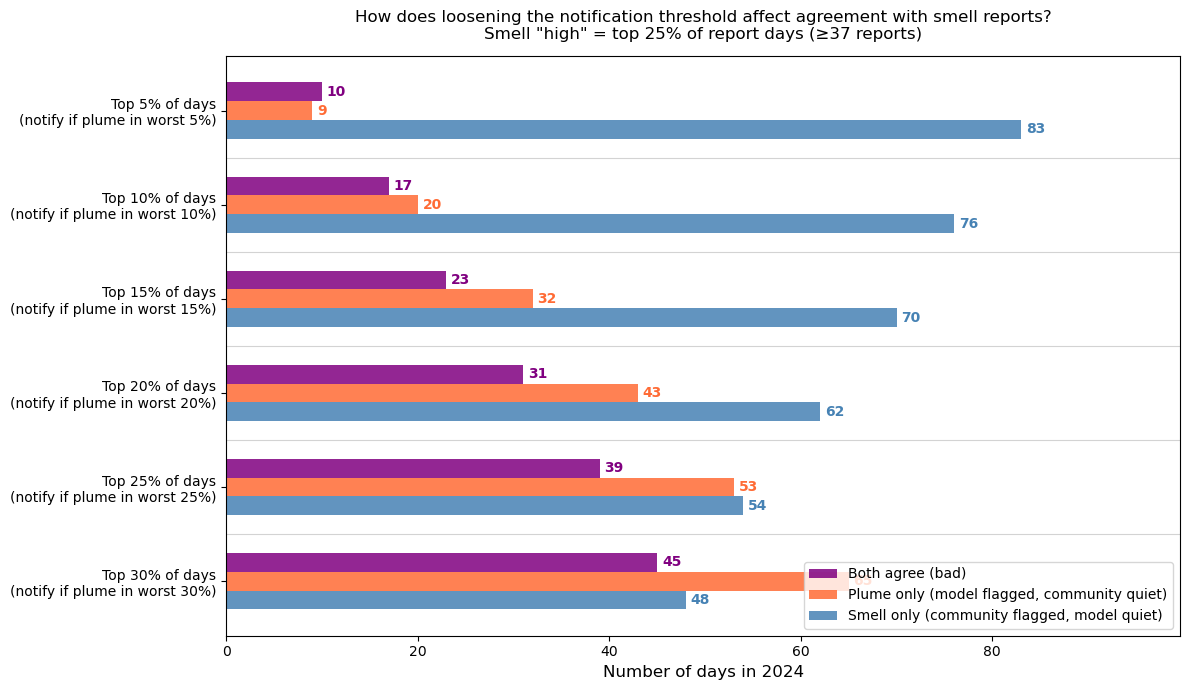

In [32]:
print('=== Threshold sensitivity on agreement split ===\n')
smell_high = merged['n_reports'].quantile(0.75)

fractions = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
rows = []
for f in fractions:
    t = plume['regional_sum'].quantile(1 - f)
    merged['notify_test'] = merged['regional_sum'] >= t
    has = merged.dropna(subset=['regional_sum'])
    both_high  = ((has['n_reports'] >= smell_high) & has['notify_test']).sum()
    plume_only = ((has['n_reports'] <  smell_high) & has['notify_test']).sum()
    smell_only = ((has['n_reports'] >= smell_high) & ~has['notify_test']).sum()
    neither    = ((has['n_reports'] <  smell_high) & ~has['notify_test']).sum()
    rows.append({
        'top_%': f'{f*100:.0f}%',
        'both_bad': both_high, 'plume_only': plume_only,
        'smell_only': smell_only, 'neither': neither
    })

sensitivity_df = pd.DataFrame(rows)

# Horizontal grouped bar chart — one row per threshold, bars = categories
fig, ax = plt.subplots(figsize=(12, 7))

y_pos     = np.arange(len(rows))
bar_h     = 0.2
colors    = {'Both agree (bad)': 'purple',
             'Plume only (model flagged, community quiet)': '#FF6B35',
             'Smell only (community flagged, model quiet)': 'steelblue'}

# Plot each category as its own row of horizontal bars
offsets = {'Both agree (bad)': -bar_h,
           'Plume only (model flagged, community quiet)': 0,
           'Smell only (community flagged, model quiet)': bar_h}
data    = {'Both agree (bad)':   [r['both_bad']   for r in rows],
           'Plume only (model flagged, community quiet)': [r['plume_only'] for r in rows],
           'Smell only (community flagged, model quiet)': [r['smell_only'] for r in rows]}

for label, values in data.items():
    bars = ax.barh(y_pos + offsets[label], values, height=bar_h,
                   color=colors[label], alpha=0.85, label=label)
    # Value labels on the end of each bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10, fontweight='bold',
                color=colors[label])

# Y axis: threshold labels
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f'Top {r["top_%"]} of days\n(notify if plume in worst {r["top_%"]})'
     for r in rows],
    fontsize=10
)

ax.set_xlabel('Number of days in 2024', fontsize=12)
ax.set_title(
    'How does loosening the notification threshold affect agreement with smell reports?\n'
    'Smell "high" = top 25% of report days (≥37 reports)',
    fontsize=12, pad=12
)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, max(r['smell_only'] for r in rows) * 1.2)

# Light horizontal grid lines between thresholds
for y in y_pos[:-1] + 0.5:
    ax.axhline(y, color='lightgrey', linewidth=0.8, linestyle='-')

ax.invert_yaxis()   # strictest threshold at the top
plt.tight_layout()
plt.savefig('agreement_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

TOP_FRACTION = 25%
Threshold value:       16317.4
Notification days:     92 / 366  (~92 days/yr)
Both agree — bad:      39
Plume only:            53
Smell only:            54
Neither:               220
Miss rate:             58.1% of high-smell days missed


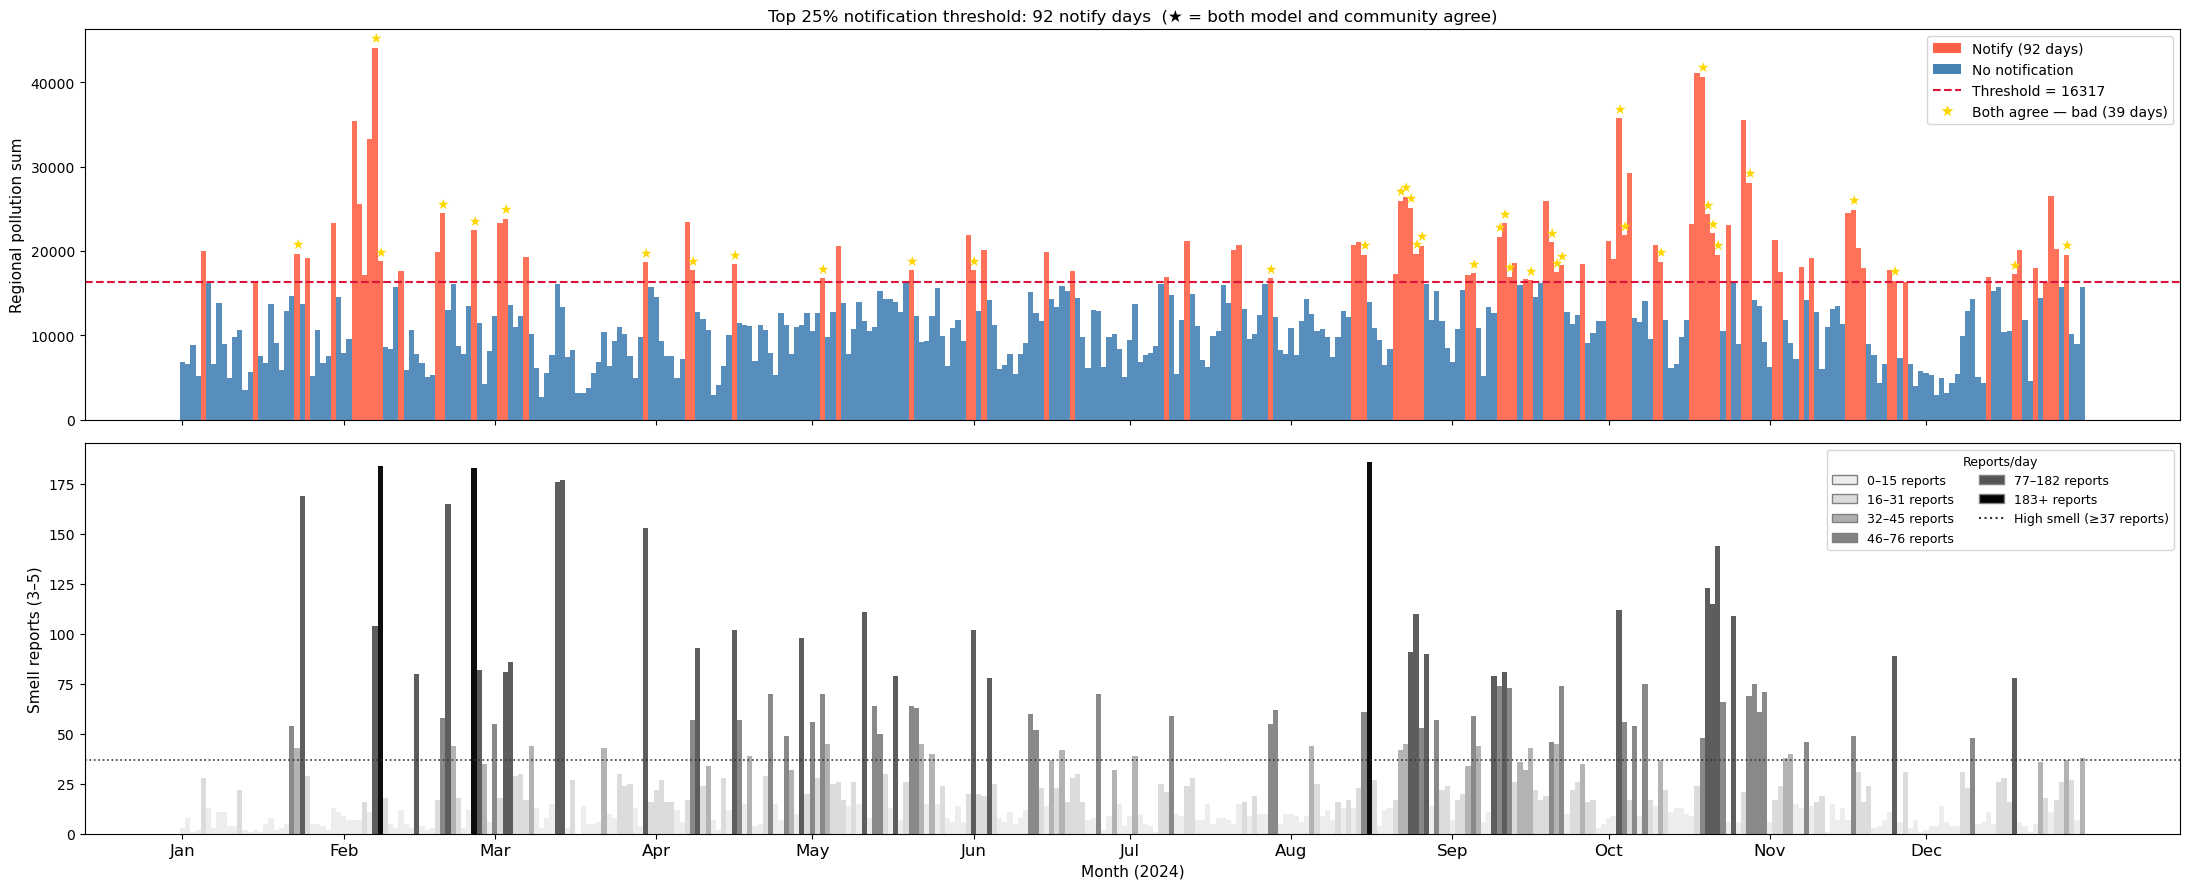

In [28]:
# Test TOP_FRACTION = 0.25
TEST_FRACTION = 0.25
test_threshold = merged['regional_sum'].quantile(1 - TEST_FRACTION)
merged['notify_25'] = merged['regional_sum'] >= test_threshold

n_notify = merged['notify_25'].sum()
smell_high = merged['n_reports'].quantile(0.75)
has = merged.dropna(subset=['regional_sum'])

both_bad   = ((has['n_reports'] >= smell_high) &  has['notify_25']).sum()
plume_only = ((has['n_reports'] <  smell_high) &  has['notify_25']).sum()
smell_only = ((has['n_reports'] >= smell_high) & ~has['notify_25']).sum()
neither    = ((has['n_reports'] <  smell_high) & ~has['notify_25']).sum()
miss_rate  = smell_only / (both_bad + smell_only) * 100

print(f'TOP_FRACTION = 25%')
print(f'Threshold value:       {test_threshold:.1f}')
print(f'Notification days:     {n_notify} / 366  (~{n_notify} days/yr)')
print(f'Both agree — bad:      {both_bad}')
print(f'Plume only:            {plume_only}')
print(f'Smell only:            {smell_only}')
print(f'Neither:               {neither}')
print(f'Miss rate:             {miss_rate:.1f}% of high-smell days missed')

# ── Timeline ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 9), sharex=True)

# Top panel: plume regional sum, notification days in red
colors_top = ['tomato' if n else 'steelblue' for n in merged['notify_25']]
ax1.bar(range(len(merged)), merged['regional_sum'],
        color=colors_top, width=1.0, alpha=0.9)
ax1.axhline(test_threshold, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Top 25% threshold = {test_threshold:.0f}')

# Annotate days where both agree — put a star above the bar
for i, (_, row) in enumerate(merged.iterrows()):
    if row['notify_25'] and row['n_reports'] >= smell_high:
        ax1.annotate('★', xy=(i, row['regional_sum']),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=10, color='gold',
                     fontweight='bold')

ax1.set_ylabel('Regional pollution sum', fontsize=11)
ax1.set_title(
    f'Top 25% notification threshold: {n_notify} notify days  '
    f'(★ = both model and community agree)',
    fontsize=12
)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',    label=f'Notify ({n_notify} days)'),
    Patch(facecolor='steelblue', label='No notification'),
    plt.Line2D([0],[0], color='crimson', linestyle='--',
               label=f'Threshold = {test_threshold:.0f}'),
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='gold',
               markersize=12, label=f'Both agree — bad ({both_bad} days)')
]
ax1.legend(handles=legend_elements, fontsize=10, loc='upper right')
ax1.tick_params(axis='y', labelsize=10)

# Bottom panel: smell reports colored by bin
for i, (_, row) in enumerate(merged.iterrows()):
    ax2.bar(i, row['n_reports'], color=row['color'], width=1.0, alpha=0.95)

# Smell high threshold line
ax2.axhline(smell_high, color='#333', linestyle=':', linewidth=1.2,
            label=f'High smell threshold (≥{smell_high:.0f} reports)')
ax2.set_ylabel('Smell reports (3–5)', fontsize=11)
ax2.tick_params(axis='y', labelsize=10)

# Smell bin legend
smell_patches = [
    mpatches.Patch(facecolor=c, edgecolor='grey', label=f'{l} reports')
    for c, l in zip(COLOR_RANGE, BIN_LABELS)
]
smell_patches.append(
    plt.Line2D([0],[0], color='#333', linestyle=':',
               label=f'High smell (≥{smell_high:.0f} reports)')
)
ax2.legend(handles=smell_patches, fontsize=9, loc='upper right',
           ncol=2, title='Reports/day', title_fontsize=9)

# Shared x axis: month labels
month_ticks, month_labels_list = [], []
for i, (_, row) in enumerate(merged.iterrows()):
    dt = pd.to_datetime(row['date_str'], format='%Y%m%d')
    if dt.day == 1:
        month_ticks.append(i)
        month_labels_list.append(dt.strftime('%b'))
ax2.set_xticks(month_ticks)
ax2.set_xticklabels(month_labels_list, fontsize=12)
ax2.set_xlabel('Month (2024)', fontsize=11)

plt.tight_layout()
plt.savefig('timeline_25pct_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Streak and gap analysis at 25% threshold
notify_vals = merged.sort_values('date')['notify_25'].values
dates = merged.sort_values('date')['date_str'].values

streaks, gaps = [], []
current_streak, current_gap = 0, 0
streak_dates, gap_dates = [], []
current_streak_start, current_gap_start = None, None

for i, (notified, date) in enumerate(zip(notify_vals, dates)):
    if notified:
        if current_gap > 0:
            gaps.append(current_gap)
            gap_dates.append((current_gap_start, dates[i-1]))
        current_gap = 0
        current_gap_start = None
        if current_streak == 0:
            current_streak_start = date
        current_streak += 1
    else:
        if current_streak > 0:
            streaks.append(current_streak)
            streak_dates.append((current_streak_start, dates[i-1]))
        current_streak = 0
        current_streak_start = None
        if current_gap == 0:
            current_gap_start = date
        current_gap += 1

if current_streak > 0:
    streaks.append(current_streak)
    streak_dates.append((current_streak_start, dates[-1]))
if current_gap > 0:
    gaps.append(current_gap)
    gap_dates.append((current_gap_start, dates[-1]))

print(f'TOP_FRACTION = 25%  |  threshold = {test_threshold:.0f}')
print(f'Total notification days: {notify_vals.sum()} / {len(notify_vals)}')
print()
print('─' * 50)
print('STREAKS (consecutive notification days)')
print('─' * 50)
print(f'  Number of streaks:     {len(streaks)}')
print(f'  Longest streak:        {max(streaks)} days')
print(f'  Average streak:        {np.mean(streaks):.1f} days')
print(f'  All streaks (longest → shortest): {sorted(streaks, reverse=True)}')
print()
print('  Streak details:')
for length, (start, end) in sorted(zip(streaks, streak_dates), reverse=True):
    start_fmt = pd.to_datetime(start, format='%Y%m%d').strftime('%b %d')
    end_fmt   = pd.to_datetime(end,   format='%Y%m%d').strftime('%b %d')
    print(f'    {length} days:  {start_fmt} → {end_fmt}')

print()
print('─' * 50)
print('GAPS (days between notification streaks)')
print('─' * 50)
print(f'  Number of gaps:        {len(gaps)}')
print(f'  Longest gap:           {max(gaps)} days')
print(f'  Average gap:           {np.mean(gaps):.1f} days')
print(f'  All gaps (longest → shortest): {sorted(gaps, reverse=True)}')
print()
print('  Gap details:')
for length, (start, end) in sorted(zip(gaps, gap_dates), reverse=True):
    start_fmt = pd.to_datetime(start, format='%Y%m%d').strftime('%b %d')
    end_fmt   = pd.to_datetime(end,   format='%Y%m%d').strftime('%b %d')
    print(f'    {length} days:  {start_fmt} → {end_fmt}')

TOP_FRACTION = 25%  |  threshold = 16317
Total notification days: 92 / 366

──────────────────────────────────────────────────
STREAKS (consecutive notification days)
──────────────────────────────────────────────────
  Number of streaks:     48
  Longest streak:        6 days
  Average streak:        1.9 days
  All streaks (longest → shortest): [6, 6, 6, 5, 4, 4, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

  Streak details:
    6 days:  Oct 17 → Oct 22
    6 days:  Aug 21 → Aug 26
    6 days:  Feb 03 → Feb 08
    5 days:  Oct 01 → Oct 05
    4 days:  Nov 16 → Nov 19
    4 days:  Sep 19 → Sep 22
    4 days:  Sep 10 → Sep 13
    3 days:  Dec 24 → Dec 26
    3 days:  Aug 13 → Aug 15
    2 days:  Dec 18 → Dec 19
    2 days:  Nov 24 → Nov 25
    2 days:  Nov 02 → Nov 03
    2 days:  Oct 27 → Oct 28
    2 days:  Oct 10 → Oct 11
    2 days:  Sep 15 → Sep 16
    2 days:  Sep 04 → Sep 05
    2 days:  Jul 21 → Ju

## Save outputs

In [ ]:
merged.to_csv('smell_plume_merged.csv', index=False)
both_high.to_csv('agreement_both_bad.csv', index=False)
plume_only.to_csv('disagreement_plume_only.csv', index=False)
smell_only.to_csv('disagreement_smell_only.csv', index=False)

print('Saved:')
print('  smell_plume_merged.csv         — full 2024 calendar with both signals')
print('  agreement_both_bad.csv         — days both signals agree are bad')
print('  disagreement_plume_only.csv    — model flagged, community quiet')
print('  disagreement_smell_only.csv    — community flagged, model quiet')
print()
print('Columns in smell_plume_merged.csv:')
print('  date_str, n_reports, mean_smell, bin_idx, color, bin_label,')
print('  regional_sum, regional_max, rank, notify')